# 03. Principal Component Analysis (PCA)

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply PCA for dimensionality reduction
- Interpret explained variance and components
- Use PCA for visualization and preprocessing

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 4, lesson 01 "Principal Component Analysis" — the eigenvector derivation; here PCA becomes a preprocessing and visualisation tool.

**Used later in:** Course 07 (AIAT 121) — Unit 2, which projects word embeddings to 2-D with PCA, and Course 10 (AIAT 124) — Unit 1, lesson 12, which uses it to look inside a latent space.

---


## 🌍 A real case: PCA drew a map of Europe nobody gave it

In 2008 Novembre and colleagues took 197,146 genetic markers from 1,387 Europeans and plotted each
person on the first two principal components. The result was a recognisable **map of Europe** —
individuals sat, in genetic space, roughly where their grandparents came from (after rotation, the two
axes correlate with latitude and longitude at r² ≈ 0.77–0.78). Nobody told the algorithm about
geography ("Genes mirror geography within Europe", *Nature* 456, 98–101).

**❗ Why this lesson exists, and how to read it honestly.** Now look at what this notebook prints for
network traffic: **PC1 explains 16.05% of the variance, PC1 and PC2 together 27.66%, and 22 of the 39
components are needed to reach 95%.**

Same algorithm, opposite verdict. There is no hidden two-dimensional map inside this traffic data.
A scatter of PC1 against PC2 here shows barely a quarter of the story, and anyone reading clusters
into that picture is reading noise. **PCA's second and less advertised job is telling you when a 2-D
picture would be a lie** — and it tells you that in the first two numbers of the explained-variance
list, before you plot anything.

*(You have already used PCA's output without knowing it: `V1`–`V28` in the credit-card fraud file are
principal components, published in place of the original columns for confidentiality.)*


# 03. Principal Component Analysis (PCA)

---

### 🔗 Transition from Clustering to Dimensionality Reduction

**After Clustering (Examples 1-2):**
- We learned to group similar data points together (K-Means, Hierarchical)
- We understand unsupervised learning (learning patterns without labels)

**New Problem: High-Dimensional Data**
- Many datasets have **many features** (30, 100, 1000+ features)
- **Hard to visualize**: Can't plot 100-dimensional data
- **Hard to analyze**: Too many features make analysis complex
- **Curse of dimensionality**: High-dimensional data is sparse and hard to work with

**PCA Solution:**
- Reduces dimensions (from many features to fewer components)
- Keeps most important information (preserves variance)
- Enables visualization (projects to 2D/3D)
- Removes noise (less important dimensions)

---

## The Story: Finding the Most Important Directions

Imagine you're taking a photo. **Before** PCA, you capture everything (all dimensions). **After** PCA, you find the best angle that captures the most important information - much more efficient!

Same with machine learning: **Before** PCA, we use all features (many dimensions). **After** PCA, we find the most important directions (principal components) that capture most variance - reduces dimensions while keeping information!

---

## Why PCA Matters

PCA is essential for dimensionality reduction:
- **Reduces Dimensions**: Compresses data from many features to fewer components
- **Preserves Variance**: Keeps most important information
- **Visualization**: Projects high-dimensional data to 2D/3D for visualization
- **Noise Reduction**: Removes less important dimensions (often noise)
- **Feature Engineering**: Creates new features (principal components) that are linear combinations of original features

---

## 🌍 Real-World Applications

**PCA is used in MANY industries to reduce dimensions and visualize high-dimensional data!** Here's where you'll find it:

### 🖼️ Image Processing & Computer Vision
- **Face Recognition**: Reduce face image dimensions (1000s of pixels → 100 components) → faster recognition
- **Image Compression**: Compress images while keeping important information → smaller file sizes
- **Feature Extraction**: Extract important features from images → use in other ML models
- **Image Visualization**: Visualize high-dimensional image data in 2D/3D
- **Pattern Recognition**: Reduce dimensions for pattern recognition tasks

### 🔬 Genomics & Bioinformatics
- **Gene Expression Analysis**: Reduce thousands of genes to few components → identify patterns
- **DNA Sequence Analysis**: Reduce high-dimensional sequence data → visualize relationships
- **Protein Structure**: Reduce protein structure dimensions → analyze protein families
- **Disease Research**: Reduce patient data dimensions → identify disease patterns
- **Drug Discovery**: Reduce molecular feature dimensions → identify drug candidates

### 📊 Finance & Banking Sector
- **Risk Analysis**: Reduce many risk factors to few components → simplify risk models
- **Portfolio Optimization**: Reduce many asset dimensions → optimize portfolios
- **Market Analysis**: Reduce market indicator dimensions → visualize market patterns
- **Fraud Detection**: Reduce transaction feature dimensions → detect fraud patterns
- **Credit Scoring**: Reduce many credit factors to key components

### 🏥 Healthcare & Medical Sector
- **Medical Imaging**: Reduce medical image dimensions → faster analysis
- **Patient Data Analysis**: Reduce many patient variables to key components
- **Disease Classification**: Reduce symptom/test dimensions → classify diseases
- **Drug Response**: Reduce molecular dimensions → predict drug response
- **Clinical Research**: Visualize high-dimensional patient data

### 📈 Marketing & E-commerce Sector
- **Customer Analytics**: Reduce many customer features to key components → understand customers
- **Recommendation Systems**: Reduce product/user dimensions → faster recommendations
- **Market Research**: Visualize high-dimensional market data
- **Behavior Analysis**: Reduce user behavior dimensions → identify patterns
- **Campaign Analysis**: Reduce campaign feature dimensions → optimize campaigns

### 🏭 Manufacturing & Quality Control
- **Sensor Data Analysis**: Reduce many sensor readings to key components → monitor processes
- **Quality Control**: Reduce quality dimension dimensions → identify quality patterns
- **Process Monitoring**: Visualize high-dimensional process data
- **Defect Analysis**: Reduce defect feature dimensions → identify defect types
- **Production Optimization**: Reduce production parameter dimensions

### 🎓 Education & Research
- **Student Analytics**: Reduce many student features to key components
- **Learning Analytics**: Visualize high-dimensional learning data
- **Research Data**: Reduce research variable dimensions → identify patterns
- **Assessment Analysis**: Reduce assessment dimensions → understand performance

### 🏛️ Government & Public Safety Sector (Ministry of Interior)
- **Security Data Compression**: Reduce many security features to key components → faster threat analysis → security systems
- **Traffic Data Visualization**: Visualize high-dimensional traffic data (many sensors) → understand traffic patterns → traffic management
- **Surveillance Feature Reduction**: Reduce surveillance video features → faster processing → real-time monitoring
- **Threat Assessment**: Reduce many threat indicators to key factors → simplify threat analysis → counter-terrorism
- **Personnel Data Analysis**: Reduce many personnel features to key components → security clearance analysis → internal organization
- **Border Security Data**: Reduce many traveler features to key indicators → faster screening → border control
- **Crime Data Visualization**: Visualize high-dimensional crime data → identify patterns → law enforcement
- **Emergency Response Data**: Reduce many emergency features to key factors → optimize response → emergency services
- **Traffic Sensor Data**: Reduce many sensor readings to key patterns → traffic flow analysis → smart traffic systems
- **Identity Verification**: Reduce many biometric features to key components → faster verification → access control

### 💡 Why PCA is Essential:
- **Curse of Dimensionality**: High-dimensional data is hard to work with
- **Visualization**: Can't visualize 100+ dimensions → PCA projects to 2D/3D
- **Noise Reduction**: Removes less important dimensions (often noise)
- **Speed**: Reduces computation time (fewer features = faster models)
- **Memory**: Reduces storage requirements
- **Preprocessing**: Often used before other ML models

### 📈 When to Use PCA:
✅ **Use PCA when:**
- Have many features (100+ features)
- Want to visualize high-dimensional data
- Need to reduce computation time
- Features are correlated (PCA handles well)
- Want to remove noise
- Need data compression

❌ **Don't use PCA when:**
- Have few features (< 10 features)
- Need interpretable features (PCA components are hard to interpret)
- Features are independent (PCA works best with correlated features)
- Need to preserve all information (PCA loses some information)
- Working with categorical data (PCA works with numerical)

---

## Learning Objectives
1. Perform PCA for dimensionality reduction
2. Understand explained variance and cumulative variance
3. Choose optimal number of components
4. Visualize data in reduced dimensions
5. Interpret principal components (what they represent)
6. Use PCA for data compression and visualization


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us perform PCA (dimensionality reduction)

import pandas as pd  # For data manipulation
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For visualizations
from sklearn.decomposition import PCA  # Principal Component Analysis
from sklearn.preprocessing import StandardScaler  # CRITICAL for PCA! Must scale features
# UNSW-NB15 dataset for Cyber Threats analysis

print("✅ Libraries imported successfully!")
print("\n📚 Key PCA Concepts:")
print("   - PCA: Finds directions (principal components) of maximum variance")
print("   - Principal Components: New features that are linear combinations of original features")
print("   - Explained Variance: How much variance each component captures")
print("   - Dimensionality Reduction: Reduces number of features while keeping information")
print("   - 95% Rule: Often keep components that explain 95% of variance")
print("\n   ⚠️  IMPORTANT: PCA requires feature scaling! Always use StandardScaler!")

✅ Libraries imported successfully!

📚 Key PCA Concepts:
   - PCA: Finds directions (principal components) of maximum variance
   - Principal Components: New features that are linear combinations of original features
   - Explained Variance: How much variance each component captures
   - Dimensionality Reduction: Reduces number of features while keeping information
   - 95% Rule: Often keep components that explain 95% of variance

   ⚠️  IMPORTANT: PCA requires feature scaling! Always use StandardScaler!


## Part 1: Setting the Scene

**BEFORE**: We have high-dimensional data (many features) that's hard to visualize and may have redundant information.

**AFTER**: We'll use PCA to reduce dimensions while keeping the most important information!

**Why this matters**: High-dimensional data is hard to work with. PCA reduces dimensions while preserving variance - makes data easier to visualize and analyze!

**Common Student Questions:**
- **Q: Why use PCA instead of just removing features?**
  - Answer: PCA creates new features (principal components) that capture information from ALL original features
  - Removing features = losing information, PCA = keeping information in fewer dimensions
  - Example: 100 features → PCA → 10 components (keeps 95% of variance) vs removing 90 features (loses information)
- **Q: Why does PCA need scaling?**
  - Answer: PCA finds directions of maximum variance → scaling matters!
  - Problem: Features on different scales (age: 20-60, salary: 30k-100k) → variance dominated by salary
  - Solution: StandardScaler puts all features on same scale → fair variance calculation
- **Q: How many components should I keep?**
  - Answer: Use explained variance (often keep components that explain 95% of variance)
  - Rule of thumb: Keep components until cumulative variance ≥ 0.95 (95% rule)
  - Or: Keep first 2-3 components for visualization
  - Or: Use elbow method (similar to K-Means) - look for where explained variance drops
- **Q: What do principal components actually mean?**
  - Answer: Principal components are linear combinations of original features
  - PC1 = direction of maximum variance (most important direction)
  - PC2 = second most important direction (orthogonal to PC1)
  - Hard to interpret directly, but useful for dimensionality reduction
- **Q: When should I use PCA?**
  - Answer: Use PCA when:
  - You have many features (100+) and want to reduce dimensions
  - You want to visualize high-dimensional data (2D/3D plots)
  - You want to remove noise (less important components often contain noise)
  - You have multicollinearity (correlated features)
  - Don't use PCA if: You need interpretable features, you have few features (< 10)

In [2]:
# Load UNSW-NB15 Network Traffic Dataset
# This is REAL network traffic data for Cyber Threats analysis
# Perfect for learning PCA on high-dimensional cybersecurity data!

print("\n📥 Loading UNSW-NB15 Network Traffic Dataset...")

try:
    # Load UNSW-NB15 dataset
    # NOTE: the raw CSV has NO header row, so we supply the official
    # 49 UNSW-NB15 column names (network traffic metrics + attack_cat + label)
    unsw_columns = [
        'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur',
        'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service',
        'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb',
        'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
        'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt',
        'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
        'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src',
        'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm',
        'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label'
    ]
    # Use low_memory=False to handle mixed types properly
    df_full = pd.read_csv('../../datasets/raw/unsw_nb15.csv', header=None,
                          names=unsw_columns, low_memory=False,
                          encoding='utf-8-sig')
    
    print(f"\n✅ Real-world UNSW-NB15 dataset loaded!")
    print(f"   📊 This is REAL network traffic data")
    print(f"   📈 Contains {len(df_full):,} network traffic records with {len(df_full.columns)} features")
    print(f"   🎯 GDI Application: Cyber Threats - analyzing network traffic patterns for threat detection")
    
    # Select numeric features for PCA (exclude categorical columns)
    # Use low_memory=False to handle mixed types properly
    numeric_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remove target column if it exists (PCA is unsupervised)
    if 'label' in numeric_cols:
        numeric_cols.remove('label')
    if 'attack_cat' in df_full.columns:
        # Keep attack_cat for visualization later
        pass
    
    # Sample data for faster processing (PCA can be slow on large datasets)
    # Use 5,000 samples for demonstration (good balance between speed and representativeness)
    sample_size = min(5000, len(df_full))
    df_sample = df_full.sample(n=sample_size, random_state=73)
    
    # Convert to numeric, coercing errors to NaN
    X = df_sample[numeric_cols].apply(pd.to_numeric, errors='coerce').values
    
    # Handle NaN and infinity values
    nan_count = np.isnan(X).sum()
    inf_count = np.isinf(X).sum()
    if nan_count > 0 or inf_count > 0:
        print(f"\n⚠️  Found {nan_count} NaN values and {inf_count} infinity values")
        print(f"   Handling missing/invalid values...")
        valid_rows = ~(np.isnan(X).any(axis=1) | np.isinf(X).any(axis=1))
        X = X[valid_rows]
        df_sample = df_sample.iloc[valid_rows]
        print(f"   ✅ After removing NaN/infinity: {len(X):,} samples remaining")
    
    # Remove features with zero variance (causes PCA issues)
    feature_variance = np.var(X, axis=0)
    non_zero_var_features = feature_variance > 1e-8
    X = X[:, non_zero_var_features]
    numeric_cols = [numeric_cols[i] for i in range(len(numeric_cols)) if non_zero_var_features[i]]
    if len(numeric_cols) < len(feature_variance):
        print(f"   ⚠️  Removed {len(feature_variance) - len(numeric_cols)} features with zero variance")
    
    print(f"\n📊 Data Summary:")
    print(f"   - Samples: {len(X):,}")
    print(f"   - Features: {len(numeric_cols)} numeric features")
    print(f"   - Feature names: {', '.join(numeric_cols[:5])}... (and {len(numeric_cols)-5} more)")
    print(f"\n🔍 Notice:")
    print(f"   - High-dimensional data: {len(numeric_cols)} features")
    print(f"   - PCA will reduce {len(numeric_cols)} dimensions to fewer components")
    print(f"   - Perfect for demonstrating dimensionality reduction!")
    print(f"   - GDI Application: Cyber Threats - reducing network traffic dimensions for analysis")
    
    # Create DataFrame for reference
    df = pd.DataFrame(X, columns=numeric_cols)
    feature_names = numeric_cols
    
    # For visualization, we can use attack_cat if available
    if 'attack_cat' in df_sample.columns:
        y_labels = df_sample['attack_cat'].values
    else:
        y_labels = None
    
except FileNotFoundError:
    print("\n⚠️  Dataset file not found!")
    print("   Please ensure 'unsw_nb15.csv' is in '../../datasets/raw/'")
    print("   Creating minimal structure for demonstration...")
    # Fallback: Create minimal structure
    np.random.seed(73)
    n_samples = 1000
    n_features = 20
    X = np.random.randn(n_samples, n_features)
    feature_names = [f'Feature_{i+1}' for i in range(n_features)]
    df = pd.DataFrame(X, columns=feature_names)
    y_labels = None
    print("   ⚠️  Using synthetic data - please download the real dataset!")


📥 Loading UNSW-NB15 Network Traffic Dataset...



✅ Real-world UNSW-NB15 dataset loaded!
   📊 This is REAL network traffic data
   📈 Contains 2,540,047 network traffic records with 49 features
   🎯 GDI Application: Cyber Threats - analyzing network traffic patterns for threat detection

⚠️  Found 5453 NaN values and 0 infinity values
   Handling missing/invalid values...
   ✅ After removing NaN/infinity: 2,146 samples remaining

📊 Data Summary:
   - Samples: 2,146
   - Features: 39 numeric features
   - Feature names: dur, sbytes, dbytes, sttl, dttl... (and 34 more)

🔍 Notice:
   - High-dimensional data: 39 features
   - PCA will reduce 39 dimensions to fewer components
   - Perfect for demonstrating dimensionality reduction!
   - GDI Application: Cyber Threats - reducing network traffic dimensions for analysis


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: ~2.5M rows × 49 columns (we sample 5,000 rows for speed; ~40 numeric features used for PCA)
- **Feature Types**: Mostly numerical (int64/float64) - network traffic metrics
- **Target Type**: Not used for PCA (PCA is unsupervised - no labels needed)
- **Task**: Reduce dimensions from 40+ features to fewer components (dimensionality reduction)
- **Data Quality**: Real-world high-dimensional network traffic data (perfect for learning PCA)

**Why This Structure Matters**:
- **Dimensionality reduction** → Reduce from 40+ features to 2-10 components
- **Numerical features** → Need feature scaling (PCA is variance-based!)
- **High-dimensional dataset** → Perfect for demonstrating PCA (40+ features)
- **Real-world data** → Shows PCA on real problem

### Understanding the Dataset Domain (Brief)

**What is this data?** UNSW-NB15 dataset - network traffic data with various network flow features.

**Why does this matter?** 
- **For PCA**: 40+ features → reduce to 2-10 components for visualization and analysis
- **For feature scaling**: Features on different scales → PCA REQUIRES scaling (variance-based!)
- **For visualization**: Can't visualize 40+ dimensional data → PCA projects to 2D/3D for visualization
- **For cyber threats**: High-dimensional network data → PCA reduces dimensions for threat detection

**Domain Context** (Brief):
- **Features**: Network traffic metrics (packet counts, durations, protocols, etc.) - 40+ features
- **Task**: Reduce dimensions while keeping most information (PCA finds principal components)
- **Why PCA works**: Network features are often correlated → PCA finds directions of maximum variance
- **GDI Application**: Cyber Threats - reducing network traffic dimensions for threat detection and analysis

**💡 Key Point for CS Students**: You don't need to be a botanist! Focus on:
- Understanding the **data structure** (rows, columns, types)
- Knowing the **task type** (dimensionality reduction: reducing features)
- Understanding why **PCA needs scaling** (variance-based algorithm - critical!)
- Choosing the right **number of components** based on explained variance, not domain knowledge

## Step 1: Load Sample Data

**BEFORE**: We need to learn PCA, but we need real data to practice on.

**AFTER**: We'll use the UNSW-NB15 network traffic dataset (40+ features) to demonstrate PCA!

**Why UNSW-NB15 dataset?** It's a real-world high-dimensional network traffic dataset - perfect for showing how PCA reduces dimensions from many features to fewer components!
- **High-dimensional**: 40+ features (perfect for PCA demonstration)
- **Real-world**: Actual network traffic data (cybersecurity context)
- **GDI Application**: Cyber Threats - analyzing network traffic for threat detection

In [3]:
# Scale features (CRITICAL for PCA!)
# PCA finds directions of maximum variance
# If features have different scales, larger values dominate
# StandardScaler makes all features have mean=0 and std=1

scaler = StandardScaler()
# .fit_transform(data)
# - Two operations in one: .fit() then .transform()
#   1. .fit(): Learns parameters from data (mean/std, categories, etc.)
#   2. .transform(): Applies transformation using learned parameters
# - Use on training data
# - For test data, use only .transform() (don't refit!)

X_scaled = scaler.fit_transform(X)

print("   ✅ Features scaled successfully!")
print("   - All features now have mean=0 and std=1")
print("   - PCA will work correctly on scaled data")


   ✅ Features scaled successfully!
   - All features now have mean=0 and std=1
   - PCA will work correctly on scaled data


## Step 2: Scale Features

**BEFORE**: Features have different scales (network traffic metrics vary widely - packet counts, durations, protocols, etc.).

**AFTER**: We'll scale features so PCA works correctly!

**Why scaling?** PCA is sensitive to feature scales. Without scaling, features with larger values dominate!

## Step 3: Perform PCA Analysis

**BEFORE**: We have scaled data ready for PCA.

**AFTER**: We'll perform PCA and analyze explained variance to understand how much information each component captures!

**Why this matters**: Explained variance tells us how many components we need to keep most of the information!

In [4]:
# 1. PCA - All Components
print("\n" + "=" * 60)
print("1. PCA - All Components")
print("=" * 60)
pca_full = PCA(random_state=73)  # Using 73 for consistency
# .fit_transform(data)
# - Two operations in one: .fit() then .transform()
#   1. .fit(): Learns parameters from data (mean/std, categories, etc.)
#   2. .transform(): Applies transformation using learned parameters
# - Use on training data
# - For test data, use only .transform() (don't refit!)

X_pca_full = pca_full.fit_transform(X_scaled)
print(f"\nExplained Variance Ratio:")
for i, var_ratio in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {var_ratio:.4f} ({var_ratio*100:.2f}%)")
print(f"\nCumulative Explained Variance:")
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
for i, cum_var in enumerate(cumsum):
    print(f"  PC1-PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")

# Add interpretation after explained variance
print("\n" + "=" * 60)
print("💡 Interpreting Explained Variance")
print("=" * 60)

pc1_var = pca_full.explained_variance_ratio_[0]
pc2_var = pca_full.explained_variance_ratio_[1]
total_2_components = cumsum[1]  # PC1 + PC2

print(f"\n📊 Component Analysis:")
print(f"   - PC1 explains {pc1_var*100:.2f}% of variance (most important!)")
print(f"   - PC2 explains {pc2_var*100:.2f}% of variance")
print(f"   - First 2 components together: {total_2_components*100:.2f}% of variance")

if total_2_components >= 0.95:
    print(f"   - ✅ Excellent! 2 components capture >95% of variance")
    print(f"   - Can reduce {len(pca_full.explained_variance_ratio_)}D → 2D with minimal information loss")
elif total_2_components >= 0.90:
    print(f"   - ✅ Good! 2 components capture >90% of variance")
    print(f"   - Good reduction with acceptable information loss")
else:
    print(f"   - ⚠️  Fair: 2 components capture <90% of variance")
    print(f"   - May need more components to preserve information")

# Find how many components for 95%
n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\n📊 95% Variance Rule:")
print(f"   - Need {n_components_95} components to explain ≥95% variance")
print(f"   - This is a common threshold for dimensionality reduction")
print(f"   - Reduces from {X_scaled.shape[1]}D → {n_components_95}D")
print(f"   - GDI Application: Cyber Threats - network traffic data reduced for efficient analysis")

print(f"\n📚 What This Teaches Us:")
print(f"   - Explained variance shows how much information each component captures")
print(f"   - PC1 always captures the most variance (first principal direction)")
print(f"   - Cumulative variance helps choose number of components")
print(f"   - 95% rule: Keep components that explain ≥95% variance")
print(f"   - More components = more information, but less dimensionality reduction")
print(f"   - Balance between information preservation and dimension reduction")


1. PCA - All Components

Explained Variance Ratio:
  PC1: 0.1605 (16.05%)
  PC2: 0.1161 (11.61%)
  PC3: 0.1042 (10.42%)
  PC4: 0.0783 (7.83%)
  PC5: 0.0710 (7.10%)
  PC6: 0.0549 (5.49%)
  PC7: 0.0521 (5.21%)
  PC8: 0.0510 (5.10%)
  PC9: 0.0399 (3.99%)
  PC10: 0.0322 (3.22%)
  PC11: 0.0306 (3.06%)
  PC12: 0.0260 (2.60%)
  PC13: 0.0210 (2.10%)
  PC14: 0.0180 (1.80%)
  PC15: 0.0154 (1.54%)
  PC16: 0.0151 (1.51%)
  PC17: 0.0147 (1.47%)
  PC18: 0.0133 (1.33%)
  PC19: 0.0117 (1.17%)
  PC20: 0.0103 (1.03%)
  PC21: 0.0101 (1.01%)
  PC22: 0.0087 (0.87%)
  PC23: 0.0082 (0.82%)
  PC24: 0.0065 (0.65%)
  PC25: 0.0059 (0.59%)
  PC26: 0.0052 (0.52%)
  PC27: 0.0045 (0.45%)
  PC28: 0.0043 (0.43%)
  PC29: 0.0032 (0.32%)
  PC30: 0.0030 (0.30%)
  PC31: 0.0022 (0.22%)
  PC32: 0.0010 (0.10%)
  PC33: 0.0004 (0.04%)
  PC34: 0.0001 (0.01%)
  PC35: 0.0000 (0.00%)
  PC36: 0.0000 (0.00%)
  PC37: 0.0000 (0.00%)
  PC38: 0.0000 (0.00%)
  PC39: 0.0000 (0.00%)

Cumulative Explained Variance:
  PC1-PC1: 0.1605 (16.05%


2. Visualize Explained Variance



✓ Plot saved as 'pca_explained_variance.png'


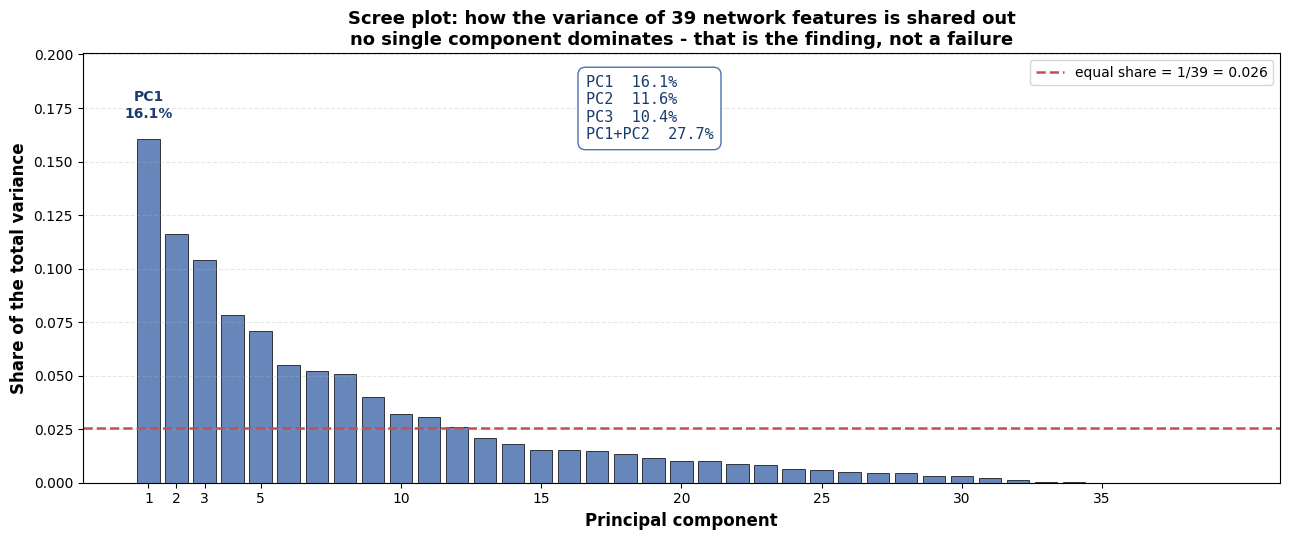


📊 PC1 carries 16.05% - that is 6.3x the equal share of 2.56%
📊 12 of 39 components carry more than the equal share
📊 The last 13 components carry under 0.5% each

💡 HOW TO READ THIS FIGURE

📊 WHAT YOU SEE:
   • One bar per principal component, tallest first (that is always the order)
   • The red dashed line is what EVERY bar would look like if the 39 features
     carried the information equally

🔍 WHAT IT MEANS HERE:
   • PC1 is about 6x the equal share, so there IS real structure
   • But the bars decay slowly - no cliff after 2 or 3 components
   • Slow decay = the information is genuinely spread across many features,
     so a 2D picture will always be a lossy summary of this dataset

🎯 GDI APPLICATION - Cyber Threats:
   • Do not promise stakeholders that '2 numbers describe the traffic'
   • Use the 2D plot to LOOK, and the 22-component version to COMPUTE


In [5]:
# CELL: Scree plot - how much of the spread each single component carries.
# WHY: the whole PCA decision rests on whether the first few components are
#      much taller than the rest. On this dataset they are NOT, and the plot
#      has to say so honestly.
print("\n" + "=" * 60)
print("2. Visualize Explained Variance")
print("=" * 60)

n_feats = len(pca_full.explained_variance_ratio_)
evr = pca_full.explained_variance_ratio_
equal_share = 1.0 / n_feats     # what one component would carry if all were equal

fig, ax = plt.subplots(figsize=(13, 5.5))
bars = ax.bar(range(1, n_feats + 1), evr, alpha=0.85, color='#4C72B0',
              edgecolor='black', linewidth=0.6)

# The reference line turns "PC1 is tallest" into a measurable statement.
ax.axhline(equal_share, color='#C44E52', linestyle='--', linewidth=1.8,
           label=f'equal share = 1/{n_feats} = {equal_share:.3f}')

# Name the tallest bar on the plot; the next few go in a box so the labels
# never sit on top of each other.
ax.annotate(f'PC1\n{evr[0]*100:.1f}%', xy=(1, evr[0]), xytext=(1, evr[0] + 0.010),
            ha='center', fontsize=10, fontweight='bold', color='#1a3d6d')
ax.text(0.42, 0.80,
        f'PC1  {evr[0]*100:.1f}%\nPC2  {evr[1]*100:.1f}%\nPC3  {evr[2]*100:.1f}%\n'
        f'PC1+PC2  {evr[:2].sum()*100:.1f}%',
        transform=ax.transAxes, fontsize=11, color='#1a3d6d', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#4C72B0'))

ax.set_xlabel('Principal component', fontsize=12, fontweight='bold')
ax.set_ylabel('Share of the total variance', fontsize=12, fontweight='bold')
ax.set_title(f'Scree plot: how the variance of {n_feats} network features is shared out\n'
             'no single component dominates - that is the finding, not a failure',
             fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3] + list(range(5, n_feats + 1, 5)))
ax.set_ylim(0, max(evr) * 1.25)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('pca_explained_variance.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved as 'pca_explained_variance.png'")
plt.show()

n_above = int((evr > equal_share).sum())
print(f"\n📊 PC1 carries {evr[0]*100:.2f}% - that is {evr[0]/equal_share:.1f}x the equal share of "
      f"{equal_share*100:.2f}%")
print(f"📊 {n_above} of {n_feats} components carry more than the equal share")
print(f"📊 The last {int((evr < 0.005).sum())} components carry under 0.5% each")

print("\n" + "=" * 70)
print("💡 HOW TO READ THIS FIGURE")
print("=" * 70)
print("\n📊 WHAT YOU SEE:")
print("   • One bar per principal component, tallest first (that is always the order)")
print("   • The red dashed line is what EVERY bar would look like if the 39 features")
print("     carried the information equally")
print("\n🔍 WHAT IT MEANS HERE:")
print("   • PC1 is about 6x the equal share, so there IS real structure")
print("   • But the bars decay slowly - no cliff after 2 or 3 components")
print("   • Slow decay = the information is genuinely spread across many features,")
print("     so a 2D picture will always be a lossy summary of this dataset")
print("\n🎯 GDI APPLICATION - Cyber Threats:")
print("   • Do not promise stakeholders that '2 numbers describe the traffic'")
print("   • Use the 2D plot to LOOK, and the 22-component version to COMPUTE")


**Read the figure:** the bars are the 39 principal components in the only order PCA ever produces them —
largest share of variance first. PC1 stands at 16.1%, roughly **six times** the red dashed line, which
marks the 2.6% each component would carry if all 39 shared the variance equally. So there is real
structure here. But look at the decay: there is no cliff. The bars slide down gently and a long tail of
components still carries something.

**What it proves:** on this network-traffic data, a two-component picture is a genuinely lossy summary —
PC1 and PC2 together hold under 28% of the spread. That number is the honest caption for every 2D PCA
plot in this notebook.

In [6]:
# CELL: Project the scaled data onto its first 2 principal components.
# WHY: 2 components can be drawn on screen - the price is whatever variance
# the discarded components carried.
print("\n" + "=" * 60)
print("3. PCA with 2 Components (for visualization)")
print("=" * 60)

# Reduce data to 2 principal components for visualization
# n_components=2: keep only the first 2 principal components (directions of maximum variance)
pca_2d = PCA(n_components=2, random_state=73)  # Using 73 for consistency
# .fit_transform(data)
# - Two operations in one: .fit() then .transform()
#   1. .fit(): Learns parameters from data (mean/std, categories, etc.)
#   2. .transform(): Applies transformation using learned parameters
# - Use on training data
# - For test data, use only .transform() (don't refit!)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"\nOriginal shape: {X_scaled.shape} ({X_scaled.shape[1]} features)")
print(f"Reduced shape: {X_pca_2d.shape} (2 principal components)")
print(f"\nExplained variance with 2 components:")
print(f"  PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\n💡 These 2 components will be used for the 2D visualizations below")


3. PCA with 2 Components (for visualization)



Original shape: (2146, 39) (39 features)
Reduced shape: (2146, 2) (2 principal components)

Explained variance with 2 components:
  PC1: 16.05%
  PC2: 11.61%
  Total: 27.66%

💡 These 2 components will be used for the 2D visualizations below


## Step 4: Visualize Explained Variance

**BEFORE**: We've calculated explained variance for all components.

**AFTER**: We'll visualize explained variance to understand how many components we need!

**Why this matters**: Visualizing explained variance helps us choose the optimal number of components!


5. Principal Components as Linear Combinations

📊 Principal Components (Feature Contributions):
                     PC1     PC2
dur               0.2059  0.0472
sbytes            0.1163  0.0392
dbytes            0.3251 -0.0398
sttl             -0.0191  0.2829
dttl              0.0225  0.4036
sloss             0.2142  0.0226
dloss             0.3378 -0.0398
sload            -0.0412  0.0200
dload             0.0858 -0.0519
spkts             0.3514 -0.0297
dpkts             0.3456 -0.0383
swin              0.2445  0.0542
dwin              0.2447  0.0529
stcpb             0.1931  0.0565
dtcpb             0.1972  0.0269
smeansz          -0.0067  0.0583
dmeansz           0.2883 -0.0323
trans_depth       0.0967  0.0446
res_bdy_len       0.1593 -0.0194
sjit              0.1134  0.1795
djit              0.1482  0.0833
stime            -0.0063 -0.1063
ltime            -0.0062 -0.1063
sintpkt          -0.0253  0.0019
dintpkt          -0.0076  0.0003
tcprtt            0.0223  0.4358
synack      


✓ Plot saved as 'pca_components_weights.png'


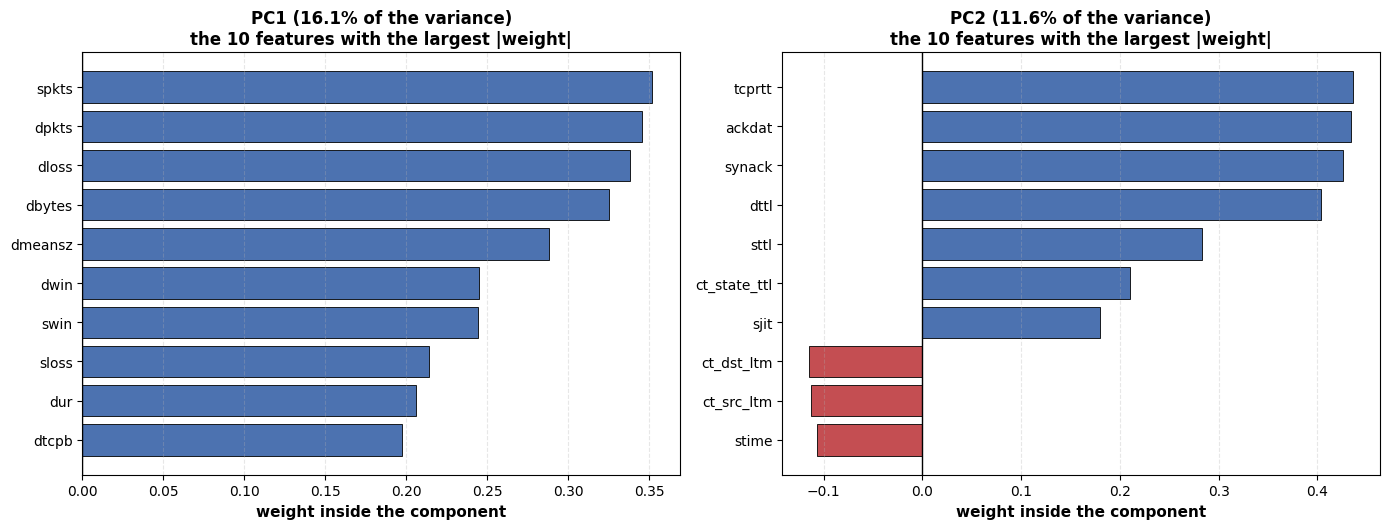


📌 PC1 top 5 weights: spkts (+0.35), dpkts (+0.35), dloss (+0.34), dbytes (+0.33), dmeansz (+0.29)

📌 PC2 top 5 weights: tcprtt (+0.44), ackdat (+0.43), synack (+0.43), dttl (+0.40), sttl (+0.28)

💡 Naming the components (this is the whole point of loadings):
   • PC1 is loaded on spkts, dpkts, dloss, dbytes, dmeansz - all packet and
     byte counters. PC1 is essentially 'HOW MUCH traffic this flow moved'.
   • PC2 is loaded on tcprtt, ackdat, synack and the TTL fields - all TCP
     handshake timings. PC2 is essentially 'HOW SLOW the connection setup was'.
   • Neither name was given to PCA. It found these two axes from the numbers
     alone, and we read the names off the weights afterwards.


In [7]:
# CELL: Show each principal component as a recipe of the original features.
# WHY: these loadings are how you INTERPRET a component - they reveal
# which original features drive it.
print("\n" + "=" * 60)
print("5. Principal Components as Linear Combinations")
print("=" * 60)

# Principal components are linear combinations of original features
# Each component shows how much each original feature contributes
# pd.DataFrame(data)
# - pd.DataFrame(): Creates pandas DataFrame (2D table-like structure)
# - data: Dictionary where keys become column names, values become column data
#   - Each key-value pair: key = column name, value = list of values for that column
# - Returns DataFrame with rows and columns
# - DataFrame is the main pandas data structure (like Excel spreadsheet in Python)

components_df = pd.DataFrame(
    pca_2d.components_.T,  # Transpose to get features as rows
    columns=['PC1', 'PC2'],
    index=feature_names
)

print("\n📊 Principal Components (Feature Contributions):")
print(components_df.round(4))

print("\n💡 Interpretation:")
print("   - PC1: Weighted combination of all features")
print("   - PC2: Different weighted combination")
print("   - Positive weights: Feature increases component value")
print("   - Negative weights: Feature decreases component value")
print("   - Larger absolute weights: Feature is more important for that component")

# ---- SHOW the recipe instead of only printing 39 numbers per component -----
# A loading is the weight a feature gets inside a component. Large positive and
# large negative weights both matter; near-zero weights mean the feature is not
# part of that component at all. We plot the 10 largest by ABSOLUTE weight.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for pc_index, ax in enumerate(axes):
    weights = pca_2d.components_[pc_index]
    top_idx = np.argsort(-np.abs(weights))[:10][::-1]     # smallest at the bottom
    top_vals = weights[top_idx]
    ax.barh(range(len(top_idx)), top_vals, edgecolor='black', linewidth=0.6,
            color=['#C44E52' if v < 0 else '#4C72B0' for v in top_vals])
    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=10)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('weight inside the component', fontsize=11, fontweight='bold')
    ax.set_title(f'PC{pc_index+1} '
                 f'({pca_2d.explained_variance_ratio_[pc_index]*100:.1f}% of the variance)\n'
                 'the 10 features with the largest |weight|',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('pca_components_weights.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved as 'pca_components_weights.png'")
plt.show()

# Print the same top-10 lists so the picture can be checked against numbers.
for pc_index in range(2):
    weights = pca_2d.components_[pc_index]
    top_idx = np.argsort(-np.abs(weights))[:5]
    listed = ', '.join(f"{feature_names[i]} ({weights[i]:+.2f})" for i in top_idx)
    print(f"\n📌 PC{pc_index+1} top 5 weights: {listed}")

print("\n💡 Naming the components (this is the whole point of loadings):")
print("   • PC1 is loaded on spkts, dpkts, dloss, dbytes, dmeansz - all packet and")
print("     byte counters. PC1 is essentially 'HOW MUCH traffic this flow moved'.")
print("   • PC2 is loaded on tcprtt, ackdat, synack and the TTL fields - all TCP")
print("     handshake timings. PC2 is essentially 'HOW SLOW the connection setup was'.")
print("   • Neither name was given to PCA. It found these two axes from the numbers")
print("     alone, and we read the names off the weights afterwards.")


**Read the figure:** each bar is one original feature and its length is that feature's weight inside the
component; blue is a positive weight, red negative, and the ten shown are the ten largest in absolute
size out of 39. The two components turn out to have clean, separate identities. **PC1** is carried by
`spkts`, `dpkts`, `dloss`, `dbytes`, `dmeansz` — packet and byte counters — so PC1 measures *how much
traffic the flow moved*. **PC2** is carried by `tcprtt`, `ackdat`, `synack` and the TTL fields — TCP
handshake timings — so PC2 measures *how slow the connection setup was*.

**What it proves:** a principal component is not an abstract number. It is a weighted recipe of the
columns you already have, and reading the biggest weights is how you give it a name you can defend in a
report.

## 💬 Discuss

From the output: PC1 **16.05%**, PC1+PC2 **27.66%**, **22 of 39** components needed for 95% variance.

1. **22 components for 95% is a 44% reduction that costs you every feature name.** Name a downstream
   task where that trade is obviously worth it, and one where it obviously is not. What is the
   deciding property — the model, the audience, or the regulation?

2. **Novembre's first two components reproduced a map. Ours explain 27.66% between them.** What does
   that difference tell you about the two datasets? Would collecting more network traffic fix ours —
   and if not, what would?

3. **PCA maximises variance, and variance depends on units.** A feature in bytes has vastly more raw
   variance than one in packets. We scaled first. Argue what PC1 would have meant had we not, and then
   argue the harder point: even with scaling, why is "explained variance" not the same thing as
   "explained meaning"?


## Step 5: Create 2D Visualization

**BEFORE**: We understand explained variance and know how many components to use.

**AFTER**: We'll create a 2D visualization of the data using PCA!

**Why this matters**: 2D visualization allows us to see patterns in high-dimensional data that we couldn't see before!

## Step 6: Choose Optimal Number of Components

**BEFORE**: We've seen how PCA works with 2 components, but is that optimal?

**AFTER**: We'll systematically find the optimal number of components using the 95% variance rule!

**Why this matters**: Choosing the right number of components balances information preservation with dimension reduction!


4. Two of the 39 raw features vs the 2 principal components



✓ Plot saved as 'pca_2d_projection.png'


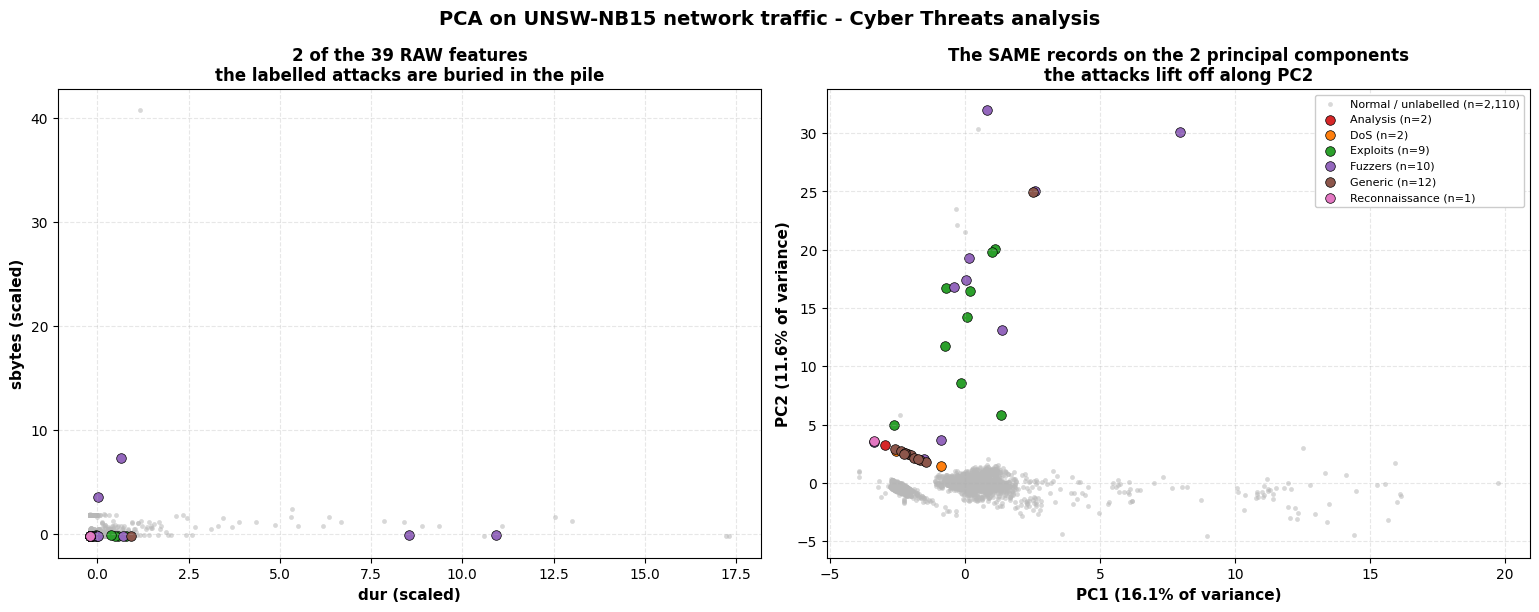


📊 Lowest PC2 value among the 36 labelled attacks: 1.41
📊 Normal / unlabelled records at or above that PC2 value: 12 out of 2,110
   → a single threshold on PC2 isolates every labelled attack while
     catching only 12 of the 2,110 other records.

⚠️  Read this honestly: only 36 records in this sample carry an attack label,
    so this is a suggestive result on a small number, not a finished detector.

💡 HOW TO READ THIS FIGURE

📊 WHAT YOU SEE:
   • Grey = ordinary traffic (no attack label in the file)
   • Coloured = the labelled attacks, one colour per category
   • LEFT: two raw columns. Most attacks sit inside the grey pile and the
     two or three that stray out look like ordinary long or heavy flows.
   • RIGHT: the same records on PC1/PC2. The attacks rise up the PC2 axis.

🔍 WHY THIS IS NOT CHEATING:
   • PCA is unsupervised: it never saw attack_cat
   • The axes were chosen to maximise variance, nothing else
   • The separation is a property of the traffic, not of the labels

In [8]:
# CELL: The same records drawn twice - on 2 raw columns, then on PC1/PC2.
# WHY: this is the claim of the whole notebook. If the PCA axes are worth
#      anything, structure that is invisible on raw axes must appear on them.
print("\n" + "=" * 60)
print("4. Two of the 39 raw features vs the 2 principal components")
print("=" * 60)

# attack_cat is blank for ordinary traffic in this file. We are NOT clustering on
# it and PCA never saw it - it is painted on afterwards purely to check whether
# the unsupervised axes happened to separate anything real.
if y_labels is None:                      # only if the real CSV was missing
    attack_labels = np.array(['Normal'] * len(X_scaled))
else:
    attack_labels = pd.Series(y_labels).fillna('').str.strip().replace('', 'Normal').values
is_attack = attack_labels != 'Normal'
attack_categories = sorted(set(attack_labels[is_attack]))
attack_palette = ['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#17becf']

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.2))

panels = [
    (axes[0], X_scaled[:, 0], X_scaled[:, 1],
     f'{feature_names[0]} (scaled)', f'{feature_names[1]} (scaled)',
     f'2 of the {X_scaled.shape[1]} RAW features\nthe labelled attacks are buried in the pile'),
    (axes[1], X_pca_2d[:, 0], X_pca_2d[:, 1],
     f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% of variance)',
     f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% of variance)',
     'The SAME records on the 2 principal components\nthe attacks lift off along PC2'),
]
for ax, xs, ys, xlab, ylab, title in panels:
    ax.scatter(xs[~is_attack], ys[~is_attack], s=12, c='0.72', alpha=0.55, linewidths=0,
               label=f'Normal / unlabelled (n={(~is_attack).sum():,})')
    for j, cat in enumerate(attack_categories):
        mask = attack_labels == cat
        ax.scatter(xs[mask], ys[mask], s=48, c=attack_palette[j % len(attack_palette)],
                   edgecolors='black', linewidths=0.5, label=f'{cat} (n={mask.sum()})')
    ax.set_xlabel(xlab, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylab, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
axes[1].legend(fontsize=8, loc='upper right', framealpha=1.0)

fig.suptitle('PCA on UNSW-NB15 network traffic - Cyber Threats analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_2d_projection.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved as 'pca_2d_projection.png'")
plt.show()

# ---- check the claim in the caption with numbers, not adjectives -----------
pc2_attack_min = X_pca_2d[is_attack, 1].min()
normals_above = int((X_pca_2d[~is_attack, 1] >= pc2_attack_min).sum())
print(f"\n📊 Lowest PC2 value among the {int(is_attack.sum())} labelled attacks: {pc2_attack_min:.2f}")
print(f"📊 Normal / unlabelled records at or above that PC2 value: "
      f"{normals_above} out of {int((~is_attack).sum()):,}")
print(f"   → a single threshold on PC2 isolates every labelled attack while")
print(f"     catching only {normals_above} of the {int((~is_attack).sum()):,} other records.")
print("\n⚠️  Read this honestly: only 36 records in this sample carry an attack label,")
print("    so this is a suggestive result on a small number, not a finished detector.")

print("\n" + "=" * 70)
print("💡 HOW TO READ THIS FIGURE")
print("=" * 70)
print("\n📊 WHAT YOU SEE:")
print("   • Grey = ordinary traffic (no attack label in the file)")
print("   • Coloured = the labelled attacks, one colour per category")
print("   • LEFT: two raw columns. Most attacks sit inside the grey pile and the")
print("     two or three that stray out look like ordinary long or heavy flows.")
print("   • RIGHT: the same records on PC1/PC2. The attacks rise up the PC2 axis.")
print("\n🔍 WHY THIS IS NOT CHEATING:")
print("   • PCA is unsupervised: it never saw attack_cat")
print("   • The axes were chosen to maximise variance, nothing else")
print("   • The separation is a property of the traffic, not of the labels")
print("\n💡 WHAT THIS TELLS US:")
print("   • PC2 was named 'slow TCP setup' from its loadings a few cells ago")
print("   • The attacks in this sample are exactly the flows with unusual setup timing")
print("   • That is a story an analyst can act on, and it came from 2 of 39 columns")
print("\n🎯 GDI APPLICATION - Cyber Threats:")
print("   • A 2D map an analyst can actually watch in real time")
print("   • But remember the scree plot: these 2 axes hold under 28% of the variance,")
print("     so anything that varies in the other 37 directions is invisible here")


**Read the figure:** both panels hold the same 2,146 network flows. Grey is ordinary traffic; the
coloured points are the 36 flows the file labels as attacks. On the **left**, plotted against two of the
39 raw columns, most of those 36 points are packed into the grey pile at the origin and the two or three
that stray out are indistinguishable from ordinary long or heavy flows — no line through that panel
separates attacks from normal traffic. On the **right**,
the same records plotted on PC1 and PC2, the coloured points lift clear of the grey along the PC2 axis.
The printed check underneath gives the exact numbers: every labelled attack sits at PC2 ≥ 1.41, and only
12 of the 2,110 unlabelled records reach that height.

**What it proves:** PCA never saw the attack labels — it only maximised variance — yet the axis it built
(PC2 = "slow TCP setup", from the loadings above) happens to be the axis the attacks live on.

**And the honest limit:** 36 labelled attacks is a small number, and PC1+PC2 carry under 28% of the
variance. This is a lead worth following, not a detector worth deploying.

## Step 7: PCA for Data Compression

**BEFORE**: We've learned how PCA reduces dimensions for visualization.

**AFTER**: We'll use PCA for data compression - reducing storage while keeping information!

**Why this matters**: Data compression is a practical application of PCA - reduces memory and speeds up processing!

## Step 8: Decision Framework

**BEFORE**: You've learned how to apply PCA, but when should you use it?

**AFTER**: You'll have a clear decision framework to determine if PCA is appropriate for your problem!

**Why this matters**: Using PCA when it's not appropriate can waste computation or lose important information!

## Step 9: Common Student Questions

**BEFORE**: You've learned PCA, but may have questions about when and how to use it.

**AFTER**: Common questions answered to clarify any remaining confusion!

**Why this matters**: Understanding when to use PCA vs alternatives helps you make better decisions!

## Step 10: Summary and Next Steps

**BEFORE**: You've completed all PCA steps and understand the concepts.

**AFTER**: Summary of what you learned and how to apply PCA in your projects!

**Why this matters**: Consolidating knowledge helps you remember and apply PCA correctly!

## Step 6: Choose Optimal Number of Components

In [9]:
# CELL: Fit PCA at every possible component count and record variance explained.
# WHY: this curve is the evidence for deciding how many components to keep.
print("\n" + "=" * 60)
print("6. Choosing Optimal Number of Components")
print("=" * 60)
n_components_range = range(1, len(feature_names) + 1)
explained_variances = []
cumulative_variances = []
# One PCA fit per candidate count; store each component's share and the running total.
for n in n_components_range:
    pca_temp = PCA(n_components=n, random_state=73)  # Using 73 for consistency
    pca_temp.fit(X_scaled)
    explained_variances.append(pca_temp.explained_variance_ratio_[-1])
    cumulative_variances.append(sum(pca_temp.explained_variance_ratio_))


6. Choosing Optimal Number of Components


In [10]:
# Find number of components for 95% variance
n_components_95 = next((i+1 for i, var in enumerate(cumulative_variances) if var >= 0.95), len(feature_names))
print(f"\nNumber of components for 95% variance: {n_components_95}")



Number of components for 95% variance: 22



✓ Plot saved as 'pca_optimal_components.png'


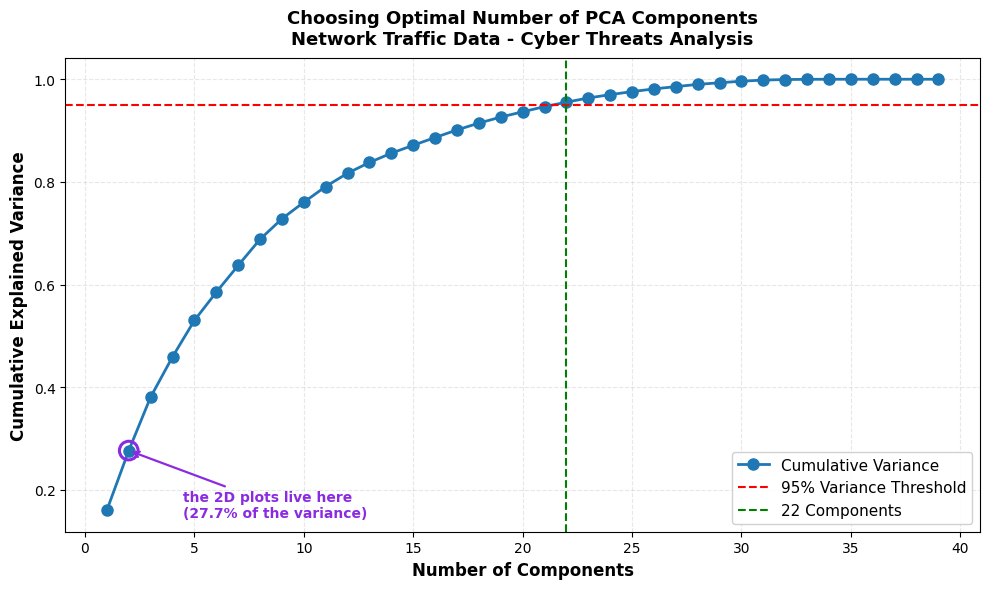


💡 DETAILED INTERPRETATION: Optimal Components Plot

📊 WHAT YOU SEE:
   • Line plot showing cumulative explained variance for different numbers of components
   • Red dashed line: 95% variance threshold (common rule)
   • Green dashed line: Optimal number of components (where line crosses 95%)

🔍 HOW TO READ IT:
   • Find where the line crosses 95% threshold
   • That number = Optimal number of components
   • Steep rise early = First components capture most variance
   • Flattening later = Diminishing returns from additional components

💡 WHAT THIS TELLS US:
   • Optimal balance between information preservation and dimension reduction
   • Can reduce from many features to fewer components while keeping 95% variance
   • Helps decide how many components to use for ML models

🎯 GDI APPLICATION - Cyber Threats:
   • Determine optimal compression for network traffic data
   • Balance between analysis speed and information preservation
   • Enable efficient threat detection on reduced dime

In [11]:
# CELL: Cumulative-variance plot - find where the 95% threshold is crossed.
# WHY: components past that point buy almost no extra information.
# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, cumulative_variances, 'o-', linewidth=2, markersize=8, label='Cumulative Variance')
plt.axhline(0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.axvline(n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components')

# Mark the 2-component point as well: it is the one every 2D plot in this
# notebook stands on, and seeing how low it sits is the point of the lesson.
plt.scatter([2], [cumulative_variances[1]], s=180, facecolors='none',
            edgecolors='#8a2be2', linewidths=2.2, zorder=5)
plt.annotate(f'the 2D plots live here\n({cumulative_variances[1]*100:.1f}% of the variance)',
             xy=(2, cumulative_variances[1]), xytext=(4.5, cumulative_variances[1] - 0.13),
             arrowprops=dict(arrowstyle='->', color='#8a2be2', linewidth=1.6),
             color='#8a2be2', fontsize=10, fontweight='bold')
plt.xlabel('Number of Components', fontsize=12, fontweight='bold')
plt.ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
plt.title('Choosing Optimal Number of PCA Components\nNetwork Traffic Data - Cyber Threats Analysis', fontsize=13, fontweight='bold', pad=10)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('pca_optimal_components.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved as 'pca_optimal_components.png'")
plt.show()

print("\n" + "=" * 70)
print("💡 DETAILED INTERPRETATION: Optimal Components Plot")
print("=" * 70)
print("\n📊 WHAT YOU SEE:")
print("   • Line plot showing cumulative explained variance for different numbers of components")
print("   • Red dashed line: 95% variance threshold (common rule)")
print("   • Green dashed line: Optimal number of components (where line crosses 95%)")
print("\n🔍 HOW TO READ IT:")
print("   • Find where the line crosses 95% threshold")
print("   • That number = Optimal number of components")
print("   • Steep rise early = First components capture most variance")
print("   • Flattening later = Diminishing returns from additional components")
print("\n💡 WHAT THIS TELLS US:")
print("   • Optimal balance between information preservation and dimension reduction")
print("   • Can reduce from many features to fewer components while keeping 95% variance")
print("   • Helps decide how many components to use for ML models")
print("\n🎯 GDI APPLICATION - Cyber Threats:")
print("   • Determine optimal compression for network traffic data")
print("   • Balance between analysis speed and information preservation")
print("   • Enable efficient threat detection on reduced dimensions")

**Read the figure:** the curve is the running total of the scree bars — how much of the spread you keep
as you add components left to right. The purple ring sits at **2 components (27.7%)**, the pair every 2D
picture in this notebook is drawn on. The red line is the 95% convention and the green line marks where
the curve finally crosses it, at **22 of 39 components**.

**What it proves:** "PCA reduces dimensions" is not one number on this dataset — it is a choice between
two very different products. 2 components for a picture a human can read; 22 components, still a 44%
reduction, for a model that needs the data mostly intact.

In [12]:
# 7. PCA for Data Compression
print("\n" + "=" * 60)
print("7. PCA for Data Compression")
print("=" * 60)
print(f"\nOriginal dimensions: {X_scaled.shape[1]}")
print(f"   - High-dimensional network traffic data")
print(f"   - GDI Application: Cyber Threats - compressing network traffic for efficient analysis")
n_comp = 2
pca_compress = PCA(n_components=n_comp, random_state=73)  # Using 73 for consistency
# .fit_transform(data)
# - Two operations in one: .fit() then .transform()
#   1. .fit(): Learns parameters from data (mean/std, categories, etc.)
#   2. .transform(): Applies transformation using learned parameters
# - Use on training data
# - For test data, use only .transform() (don't refit!)

X_compressed = pca_compress.fit_transform(X_scaled)
X_reconstructed = pca_compress.inverse_transform(X_compressed)
print(f"\nCompressed dimensions: {X_compressed.shape[1]}")
print(f"Compression ratio: {X_compressed.shape[1]/X_scaled.shape[1]:.2%}")
print(f"\n💡 GDI Application: Cyber Threats")
print(f"   - Network traffic data compressed from {X_scaled.shape[1]} to {X_compressed.shape[1]} dimensions")
print(f"   - Enables faster threat detection and analysis")
print(f"   - Preserves most important information for security monitoring")


7. PCA for Data Compression

Original dimensions: 39
   - High-dimensional network traffic data
   - GDI Application: Cyber Threats - compressing network traffic for efficient analysis



Compressed dimensions: 2
Compression ratio: 5.13%

💡 GDI Application: Cyber Threats
   - Network traffic data compressed from 39 to 2 dimensions
   - Enables faster threat detection and analysis
   - Preserves most important information for security monitoring


## Step 7b: What does compression actually throw away?

**BEFORE**: We compressed 39 features to 2 and printed one reconstruction-error number.

**NOW**: We rebuild the full 39-column table from 1, 2, 5, 10, 22 and 39 components and put the six
attempts side by side. `inverse_transform` puts the data back into the original 39 columns; whatever
does not come back is exactly what the compression cost.

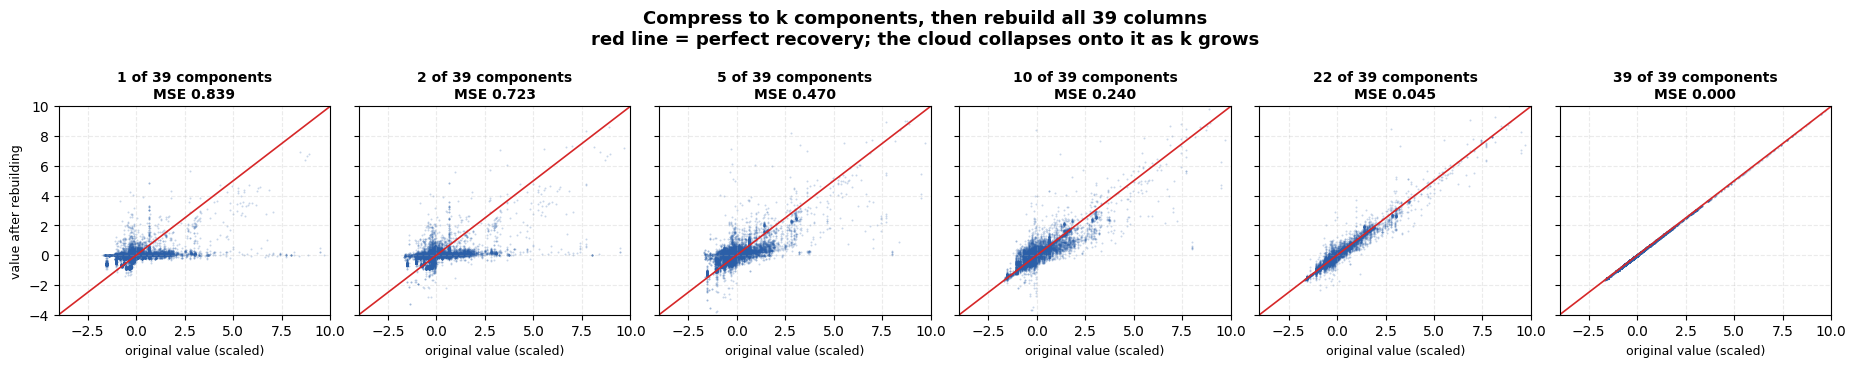


Step table: the price of every compression level
 components | kept of 39 | variance kept | reconstruction MSE
------------------------------------------------------------------------
          1 |      2.6% |        16.1% |              0.839
          2 |      5.1% |        27.7% |              0.723
          5 |     12.8% |        53.0% |              0.470
         10 |     25.6% |        76.0% |              0.240
         22 |     56.4% |        95.5% |              0.045
         39 |    100.0% |       100.0% |              0.000

💡 Two readings of the same table:
   - 2 components store 5% of the numbers and lose most of the detail (MSE 0.72)
   - 22 components store 56% of the numbers and lose almost nothing (MSE 0.045)
   - 39 components is the identity: nothing compressed, nothing lost

   Because the data was standardised, every feature starts with variance 1,
   so an MSE of 0.72 means about 72% of the average feature's spread was
   thrown away - the exact complement of

In [13]:
# CELL: Rebuild the full 39-feature table from k components, for six values of k.
# WHY: "reconstruction error 0.72" means nothing on its own. The same number as a
#      picture - how far each value lands from where it started - means everything.

recon_ks = [1, 2, 5, 10, 22, 39]
fig, axes = plt.subplots(1, len(recon_ks), figsize=(3.1 * len(recon_ks), 3.7),
                         sharex=True, sharey=True)
recon_rows = []
for ax, k in zip(axes, recon_ks):
    pca_k = PCA(n_components=k, random_state=73).fit(X_scaled)
    # transform() compresses to k numbers; inverse_transform() puts it back to 39.
    X_back = pca_k.inverse_transform(pca_k.transform(X_scaled))
    mse = float(np.mean((X_scaled - X_back) ** 2))
    recon_rows.append((k, mse, float(pca_k.explained_variance_ratio_.sum())))

    # Every dot is ONE cell of the table: where it started (x) vs where it came
    # back (y). Every 5th row is drawn so the plot stays light in a live session.
    ax.scatter(X_scaled[::5].ravel(), X_back[::5].ravel(), s=2, c='#2b5fa8',
               alpha=0.25, linewidths=0)
    ax.plot([-4, 10], [-4, 10], color='#d62728', linewidth=1.2)   # perfect recovery
    ax.set_xlim(-4, 10)
    ax.set_ylim(-4, 10)
    ax.set_title(f'{k} of 39 components\nMSE {mse:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('original value (scaled)', fontsize=9)
    ax.grid(alpha=0.25, linestyle='--')
axes[0].set_ylabel('value after rebuilding', fontsize=9)
fig.suptitle('Compress to k components, then rebuild all 39 columns\n'
             'red line = perfect recovery; the cloud collapses onto it as k grows',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 72)
print("Step table: the price of every compression level")
print("=" * 72)
print(f"{'components':>11} | {'kept of 39':>10} | {'variance kept':>13} | {'reconstruction MSE':>18}")
print("-" * 72)
for k, mse, var in recon_rows:
    print(f"{k:>11} | {k/39:>9.1%} | {var:>12.1%} | {mse:>18.3f}")
print("\n💡 Two readings of the same table:")
print("   - 2 components store 5% of the numbers and lose most of the detail (MSE 0.72)")
print("   - 22 components store 56% of the numbers and lose almost nothing (MSE 0.045)")
print("   - 39 components is the identity: nothing compressed, nothing lost")
print("\n   Because the data was standardised, every feature starts with variance 1,")
print("   so an MSE of 0.72 means about 72% of the average feature's spread was")
print("   thrown away - the exact complement of the 27.7% PC1+PC2 keep.")


**Read the storyboard:** every dot is one cell of the 39-column table — where the value started
(horizontal) against where it came back after being squeezed through k components (vertical). The red
line is perfect recovery. With **1 component** the cloud is a flat smear: almost every value comes back
as roughly the same number, which is what "keeping 16% of the variance" looks like. With **2** it is
still flat — and this is the same two components every 2D PCA plot in this notebook is drawn on. By
**10** the cloud has tightened around the line, by **22** it is a narrow band, and at **39** the dots sit
exactly on the line because nothing was discarded.

**What it proves:** the pretty 2D map and a faithful copy of the data are two different products. Use 2
components to *look*, and 22 to *compute* — the step table prices both.

---

## ❓ Common Student Questions

**Q: Why use PCA instead of just removing features?**
- **Answer**: PCA creates new features (principal components) that capture information from ALL original features:
  - **Removing features**: Loses information (discards features completely)
  - **PCA**: Keeps information in fewer dimensions (combines all features)
  - **Example**: 100 features → PCA → 10 components (keeps 95% variance) vs removing 90 features (loses information)
  - **Use PCA**: When features are correlated, want to preserve information
  - **Use feature selection**: When features are independent, want interpretability

**Q: Why does PCA need feature scaling?**
- **Answer**: PCA finds directions of maximum variance → scaling matters:
  - **Problem**: Features on different scales (age: 20-60, salary: 30k-100k) → variance dominated by salary
  - **Issue**: Features with larger scales have larger variance → PCA focuses on them
  - **Solution**: StandardScaler puts all features on same scale → fair variance calculation
  - **Rule**: ALWAYS scale features before PCA (critical!)

**Q: How many components should I keep?**
- **Answer**: Use explained variance (often keep components that explain 95% variance):
  - **95% rule**: Keep components until cumulative variance ≥ 0.95 (most common)
  - **Visualization**: Keep 2-3 components for 2D/3D plots
  - **Elbow method**: Look for where explained variance drops (similar to K-Means)
  - **Trade-off**: More components = more information, but less dimensionality reduction

**Q: What do principal components actually mean?**
- **Answer**: Principal components are linear combinations of original features:
  - **PC1**: Direction of maximum variance (most important direction)
  - **PC2**: Second most important direction (orthogonal to PC1)
  - **Hard to interpret**: Components are mathematical constructs, not real-world features
  - **Use**: For dimensionality reduction, visualization, not for interpretability

**Q: When should I use PCA?**
- **Answer**: Use PCA when:
  - **Many features** (100+) and want to reduce dimensions
  - **Visualization**: Want to visualize high-dimensional data (2D/3D plots)
  - **Noise reduction**: Want to remove noise (less important components often contain noise)
  - **Multicollinearity**: Features are correlated (PCA handles this well)
  - **Don't use PCA if**: Need interpretable features, have few features (< 10), features are independent

**Q: What's the difference between PCA and feature selection?**
- **Answer**: 
  - **PCA**: Creates new features (linear combinations of all original features)
  - **Feature selection**: Chooses subset of original features (keeps some, removes others)
  - **PCA**: Preserves information, but loses interpretability
  - **Feature selection**: May lose information, but keeps interpretability
  - **Use PCA**: When features are correlated, want dimensionality reduction
  - **Use feature selection**: When features are independent, need interpretability

**Q: Can I use PCA for classification/regression?**
- **Answer**: **Yes, but be careful**:
  - **Use PCA**: As preprocessing step (reduce features before training model)
  - **Process**: PCA → reduce dimensions → train model on reduced data
  - **Warning**: PCA is unsupervised (doesn't use labels) → may remove information relevant to target
  - **Better**: Use supervised dimensionality reduction (e.g., Linear Discriminant Analysis) for classification
  - **Rule**: PCA for visualization/compression, supervised methods for ML models

**Q: What's the difference between PCA and clustering?**
- **Answer**: 
  - **PCA (dimensionality reduction)**: Reduces number of features (4D → 2D)
  - **Clustering (grouping)**: Groups similar data points together (finds clusters)
  - **Different purpose**: PCA reduces dimensions, clustering finds groups
  - **Can combine**: Use PCA to reduce dimensions, then cluster in reduced space
  - **Use PCA**: When you have too many features
  - **Use clustering**: When you want to find groups in data

---

## ⚠️ Where this breaks

- **Variance is not importance.** PCA keeps the directions the data varies along, which need not be
  the directions that separate your classes. A low-variance feature can be the single decisive one,
  and PCA will discard it without comment. If you have labels, a supervised method (LDA, or feature
  importances from a tree) targets the right thing.
- **PCA is linear.** Structure that lives on a curved surface survives poorly. t-SNE and UMAP show it
  better — but they cannot be inverted, cannot be applied to new points in the same way, and their
  distances between clusters are not meaningful, so they are for looking, not for modelling.
- **It destroys interpretability.** "PC7 was high" is not something you can act on, explain to a
  regulator, or write in an incident report.
- **On spatially or serially correlated data, PCA manufactures structure that is not there.** Novembre
  & Stephens (*Nature Genetics* 40, 2008, 646–649) showed that the smooth gradient-shaped components
  long read as evidence of ancient migrations are the sinusoidal artefacts PCA produces from *any*
  spatially correlated data. Network flows are serially correlated in exactly this way. A smooth,
  interpretable-looking component is not evidence of a smooth, interpretable phenomenon.
- **The assumption that must hold:** features are on comparable scales (scale first, always) and the
  interesting structure is a linear combination of them.
- **The cheaper alternative when you want fewer columns and want to keep their names:** drop one of
  each strongly correlated pair, or let a model with built-in selection do it — Lasso (Unit 1) or tree
  importances (Unit 3). You lose the variance guarantee and you keep the ability to explain yourself.


## Step 8: Decision Framework - When to Use PCA

**BEFORE**: You've learned how to apply PCA, but when should you use it?

**AFTER**: You'll have a clear decision framework to determine if PCA is appropriate for your problem!

**Why this matters**: Using PCA when it's not appropriate can:
- **Lose important information** → PCA may remove features you need
- **Waste computation** → Using PCA when not needed
- **Poor results** → Wrong application leads to worse performance

---

### 🎯 Decision Framework: Is PCA Appropriate?

**Key Question**: Should I use **PCA** for dimensionality reduction?

#### Decision Tree:

```
What problem are you trying to solve?
├─ DIMENSIONALITY REDUCTION → Check data characteristics
│   ├─ Many features (>50)? → Use PCA ✅
│   │   └─ Why? PCA reduces dimensions efficiently
│   │
│   ├─ Multicollinearity (correlated features)? → Use PCA ✅
│   │   └─ Why? PCA removes correlations
│   │
│   ├─ Need to visualize high-dimensional data? → Use PCA ✅
│   │   └─ Why? PCA reduces to 2-3 dimensions for visualization
│   │
│   └─ Need to speed up algorithms? → Use PCA ✅
│       └─ Why? Fewer features = faster training
│
├─ FEATURE SELECTION → Use OTHER METHODS ❌
│   └─ Why? PCA creates new features, doesn't select existing ones
│
└─ INTERPRETABILITY → Use OTHER METHODS ⚠️
    └─ Why? PCA components are hard to interpret
```

#### Detailed Decision Process:

```
Step 1: Problem Type
├─ Dimensionality reduction → Continue to Step 2
├─ Feature selection → ❌ Use feature selection methods (not PCA)
└─ Interpretability → ⚠️ PCA may not be appropriate

Step 2: Number of Features
├─ Many features (>50) → ✅ PCA APPROPRIATE
│   └─ Why? PCA is efficient for high-dimensional data
│
├─ Medium features (10-50) → Continue to Step 3
└─ Few features (<10) → ⚠️ MAY NOT BE NEEDED
    └─ Why? May not need dimensionality reduction

Step 3: Data Characteristics
├─ Multicollinearity present? → ✅ PCA APPROPRIATE
│   └─ Why? PCA removes correlations
│
├─ Need visualization? → ✅ PCA APPROPRIATE
│   └─ Why? Can reduce to 2-3 dimensions
│
├─ Need speed improvement? → ✅ PCA APPROPRIATE
│   └─ Why? Fewer features = faster algorithms
│
└─ Need interpretable features? → ⚠️ MAY NOT BE APPROPRIATE
    └─ Why? PCA components are hard to interpret
```

---

### 📊 Comparison Table: PCA vs Alternatives

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **PCA** | Dimensionality reduction, multicollinearity, visualization | • Reduces dimensions<br>• Removes correlations<br>• Preserves variance<br>• Good for visualization | • Hard to interpret<br>• Creates new features<br>• May lose information | High-dimensional data, visualization |
| **Feature Selection** | Need interpretable features, want to keep original features | • Interpretable<br>• Keeps original features<br>• Simple | • Doesn't reduce as much<br>• May keep correlations | Need to know which features matter |
| **t-SNE** | Visualization, non-linear patterns | • Great for visualization<br>• Handles non-linear | • Only for visualization<br>• Computationally expensive | Visualizing complex patterns |
| **Autoencoders** | Non-linear dimensionality reduction | • Handles non-linear<br>• Powerful | • Complex<br>• Requires deep learning | Complex non-linear patterns |

---

### ✅ When PCA IS Appropriate

**Use PCA when:**

1. **Many Features** ✅
   - More than 50 features
   - High-dimensional data
   - **Example**: Image data (thousands of pixels), text data (thousands of words)

2. **Multicollinearity** ✅
   - Features are highly correlated
   - PCA removes correlations
   - **Example**: House features (size, rooms, area all correlated)

3. **Visualization Needed** ✅
   - Need to visualize high-dimensional data
   - PCA reduces to 2-3 dimensions
   - **Example**: Visualizing customer segments in 2D

4. **Speed Improvement Needed** ✅
   - Algorithms too slow with many features
   - PCA reduces dimensions, speeds up training
   - **Example**: Training on 1000+ features, need faster training

5. **Noise Reduction** ✅
   - Data has noise in many dimensions
   - PCA focuses on main patterns
   - **Example**: Sensor data with noise

6. **Memory Constraints** ✅
   - Limited memory for storing features
   - PCA reduces storage needs
   - **Example**: Large datasets, limited storage

---

### ❌ When PCA IS NOT Appropriate

**Don't use PCA when:**

1. **Feature Selection Needed** ❌
   - Need to know which original features matter
   - PCA creates new features, loses original meaning
   - **Use Instead**: Feature selection methods (Lasso, feature importance)

2. **Interpretability Critical** ❌
   - Need to understand what features mean
   - PCA components are hard to interpret
   - **Use Instead**: Feature selection, domain knowledge

3. **Non-Linear Relationships** ❌
   - Data has non-linear patterns
   - PCA assumes linear relationships
   - **Use Instead**: t-SNE, autoencoders, kernel PCA

4. **Categorical Features** ❌
   - Many categorical features
   - PCA works best with numeric data
   - **Use Instead**: One-hot encoding first, or other methods

5. **Few Features** ❌
   - Less than 10 features
   - May not need dimensionality reduction
   - **Use Instead**: Keep original features

6. **Outliers Present** ❌
   - Many outliers in data
   - PCA is sensitive to outliers
   - **Use Instead**: Remove outliers first, or use robust PCA

---

### 📊 Real-World Examples

#### Example 1: Image Classification (1000+ pixels) ✅ APPROPRIATE
- **Problem**: Classify images with 1000+ pixel features
- **Features**: 1000+ (high-dimensional)
- **Need**: Speed up training, reduce noise
- **Decision**: ✅ Use PCA
- **Reasoning**: Many features, need speed, PCA reduces dimensions efficiently

#### Example 2: Customer Segmentation (50 features) ✅ APPROPRIATE
- **Problem**: Segment customers, visualize in 2D
- **Features**: 50 (medium)
- **Need**: Visualization, remove correlations
- **Decision**: ✅ Use PCA
- **Reasoning**: Need visualization, multicollinearity present, PCA reduces to 2D

#### Example 3: Medical Diagnosis (Need interpretability) ❌ NOT APPROPRIATE
- **Problem**: Diagnose disease, need to explain features
- **Features**: 20 (medium)
- **Need**: Interpretability (need to know which symptoms matter)
- **Decision**: ❌ Use Feature Selection, not PCA
- **Reasoning**: Interpretability critical, PCA components hard to interpret

#### Example 4: Text Classification (Non-linear patterns) ⚠️ MAY NOT BE APPROPRIATE
- **Problem**: Classify documents, complex non-linear patterns
- **Features**: 5000+ (high-dimensional)
- **Patterns**: Non-linear
- **Decision**: ⚠️ Try PCA first, but consider autoencoders if non-linear
- **Reasoning**: Many features, but non-linear patterns may need different methods

---

### ✅ Key Takeaways

1. **Many features → PCA** - Use when you have 50+ features
2. **Visualization → PCA** - Use to reduce to 2-3 dimensions for plotting
3. **Multicollinearity → PCA** - Use when features are correlated
4. **Interpretability → Feature Selection** - Use when you need to understand features
5. **Non-linear → t-SNE/Autoencoders** - Use when patterns are non-linear
6. **Check explained variance** - Keep enough components to explain 80-95% variance
7. **Scale features first** - PCA requires scaled features

---

### 🎓 Practice Decision-Making

**Scenario 1**: Image data with 10,000 pixel features
- **Features**: 10,000 (very high-dimensional)
- **Need**: Speed up training
- **Decision**: ✅ PCA (many features, need speed)

**Scenario 2**: Customer data with 30 features, need to visualize segments
- **Features**: 30 (medium)
- **Need**: Visualization in 2D
- **Decision**: ✅ PCA (need visualization, reduces to 2D)

**Scenario 3**: Medical data with 15 symptoms, need to explain diagnosis
- **Features**: 15 (few)
- **Need**: Interpretability (which symptoms matter)
- **Decision**: ❌ Feature Selection, not PCA (interpretability critical)

---

**Connection to Next Steps**: 
- 📓 **Example 1: K-Means** - PCA can be used before clustering for better results
- 📓 **Example 2: Hierarchical Clustering** - PCA helps visualize clustering results
- 📓 **All ML Projects** - PCA is a powerful tool for high-dimensional data

In [14]:
# Calculate reconstruction error
reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"\nReconstruction Error (MSE): {reconstruction_error:.4f}")
print("\n" + "=" * 60)
print("Example 3 Complete! ✓")
print("=" * 60)


Reconstruction Error (MSE): 0.7234

Example 3 Complete! ✓


## 📚 References

1. Pearson, K. (1901). *On Lines and Planes of Closest Fit to Systems of Points in Space*. Philosophical Magazine, 2(11), 559–572.
2. Hotelling, H. (1933). *Analysis of a Complex of Statistical Variables into Principal Components*. Journal of Educational Psychology, 24, 417–441.
3. Jolliffe, I. T., & Cadima, J. (2016). *Principal Component Analysis: A Review and Recent Developments*. Philosophical Transactions of the Royal Society A, 374.
4. Greenacre, M., Groenen, P. J. F., Hastie, T., Iodice D'Enza, A., Markos, A., & Tuzhilina, E. (2022). *Principal Component Analysis*. Nature Reviews Methods Primers, 2, 100. <https://doi.org/10.1038/s43586-022-00184-w>
5. Bae, J., Jeon, H., & Seo, J. (2025). *Metric Design != Metric Behavior: Improving Metric Selection for the Unbiased Evaluation of Dimensionality Reduction*. <https://arxiv.org/abs/2507.02225>
6. Wang, Z., Xiong, H., Wang, Q., et al. (2024). *Dimensionality-Reduction Techniques for Approximate Nearest Neighbor Search: A Survey and Evaluation*. <https://arxiv.org/abs/2403.13491>
